# Lab 4: Neural networks 

In this lab we will build dense neural networks on the MNIST dataset.

Make sure you read the tutorial for this lab first.

## Load the data and create train-test splits

In [14]:
# Auto-setup when running on Google Colab
if 'google.colab' in str(get_ipython()):
    !pip install openml

# General imports
%matplotlib inline
import numpy as np
import pandas as pd
import openml as oml
import matplotlib.pyplot as plt
import pytorch_lightning as pl
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

C:\Users\20202369\AppData\Local\Temp\ipykernel_26368\3841004139.py:3: FutureWarning: Support for `dataset_format='array'` will be removed in 0.15,start using `dataset_format='dataframe' to ensure your code will continue to work. You can use the dataframe's `to_numpy` function to continue using numpy arrays.
  X, y, _, _ = mnist.get_data(target=mnist.default_target_attribute, dataset_format='array');


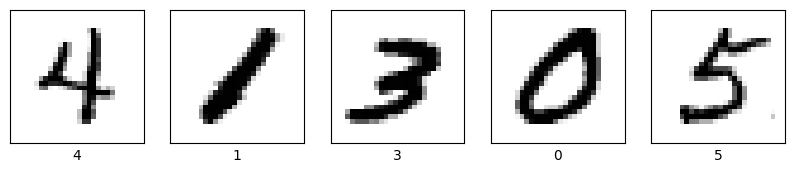

In [15]:
# Download MNIST data. Takes a while the first time.
mnist = oml.datasets.get_dataset(554)
X, y, _, _ = mnist.get_data(target=mnist.default_target_attribute, dataset_format='array');
X = X.reshape(70000, 28, 28)

# Take some random examples
from random import randint
fig, axes = plt.subplots(1, 5,  figsize=(10, 5))
for i in range(5):
    n = randint(0,70000)
    axes[i].imshow(X[n], cmap=plt.cm.gray_r)
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    axes[i].set_xlabel("{}".format(y[n]))
plt.show();

In [16]:
# For MNIST, there exists a predefined stratified train-test split of 60000-10000. We therefore don't shuffle or stratify here.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, random_state=0)

## Exercise 1: Preprocessing
* Normalize the data: map each feature value from its current representation (an integer between 0 and 255) to a floating-point value between 0 and 1.0. 
* Create a train-test split using the first 60000 examples for training
* Flatten the data
* Convert the data (numpy arrays) to PyTorch tensors
* Create a TensorDataset for the training data, and another for the testing data

In [17]:
from torch.utils.data import TensorDataset

# Normalize the data
X = X/255

# Flatten the data
X = X.reshape(70000, 28*28)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60000, random_state=0)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=50000, random_state=0)


# Convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_val_tensor = torch.tensor(X_test, dtype=torch.float32)
y_val_tensor = torch.tensor(y_test, dtype=torch.long)

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)


## Exercise 2: Create a deep neural net model

Implement a `create_model` function which defines the topography of the deep neural net, specifying the following:

* The number of layers in the deep neural net: Use 2 dense layers for now (one hidden en one output layer)
* The number of nodes in each layer: these are parameters of your function.
* Any regularization layers. Add at least one dropout layer.

Consider:
* What should be the shape of the input layer?
* Which activation function you will need for the last layer, since this is a 10-class classification problem?

In [18]:
import torch.nn as nn
import torch.nn.functional as F

### Create and compile a 'deep' neural net
def create_model(layer_1_units=512, layer_2_units=128, layer_3_units = 10, dropout_rate=0.3):
    class FFN(nn.Module):
        def __init__(self):
            super(FFN, self).__init__()
            self.fc1 = nn.Linear(28*28, layer_1_units)
            self.fc2 = nn.Linear(layer_1_units, layer_2_units)
            self.fc3 = nn.Linear(layer_2_units, layer_3_units)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.dropout(x, dropout_rate, training=self.training)
            x = F.relu(self.fc2(x))
            x = self.fc3(x)

            return x

    return FFN()
            

## Exercise 3: Create a training function
Implement a `train_model` function which trains and evaluates a given model.
It should print out the train and validation loss and accuracy.

In [19]:
import torchmetrics
import torch.optim as optim

if torch.cuda.is_available():         # For CUDA based systems
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Used device: {device}")

Used device: cpu


In [20]:
def train_model(model, train_dataset, val_dataset, epochs=10, batch_size=64, learning_rate=0.001):
    """
    model: the model to train
    train_dataset: the training data and labels
    test_dataset: the test data and labels
    epochs: the number of epochs to train for
    batch_size: the batch size for minibatch SGD
    learning_rate: the learning rate for the optimizer
    """

    history = {
        'accuracy': [],
        'val_accuracy': [],
        'loss': [],
        'val_loss': []
    }

    cross_entropy = nn.CrossEntropyLoss(label_smoothing=0.01)
    optimizer = optim.RMSprop(model.parameters(), lr=0.001, momentum=0.0)
    accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=10)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=4, shuffle=True, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, num_workers=4, shuffle=False, pin_memory=False)
   
    for epoch in range(epochs):

        model.train()
        
        total_loss, correct, total = 0, 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass + loss calculation
            outputs = model(X_batch)
            loss = cross_entropy(outputs, y_batch)

            # Backward pass: zero gradients, do backprop, do optimizer step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute training metrics
            total_loss += loss.item()
            correct += accuracy_metric(outputs, y_batch).item() * y_batch.size(0)
            total += y_batch.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                
                val_outputs = model(X_val)
                v_loss = cross_entropy(val_outputs, y_val)
                
                val_loss += v_loss.item()
                val_correct += accuracy_metric(val_outputs, y_val).item() * y_val.size(0)
                val_total += y_val.size(0)
       
        # Compute epoch validation metrics
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / val_total

        # Compute epoch metrics
        avg_loss = total_loss / len(train_loader)
        avg_acc = correct / total

        # Update history
        history['accuracy'].append(avg_acc)
        history['val_accuracy'].append(avg_val_acc)
        history['loss'].append(avg_loss)
        history['val_loss'].append(avg_val_loss)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}")

    return history


## Exercise 4: Evaluate the model

Train the model with a learning rate of 0.003, 50 epochs, batch size 4000, and a validation set that is 20% of the total training data.

Use default settings otherwise. Plot the learning curve of the loss, validation loss, accuracy, and validation accuracy. Finally, report the performance on the test set.

Try to run the model on GPU.

Feel free to use the plotting function below, or implement the callback from the tutorial to see results in real time.

Epoch [1/10], Loss: 0.3148, Accuracy: 0.9242, Val Loss: 0.2004, Val Accuracy: 0.9617
Epoch [2/10], Loss: 0.1888, Accuracy: 0.9662, Val Loss: 0.1843, Val Accuracy: 0.9677
Epoch [3/10], Loss: 0.1589, Accuracy: 0.9767, Val Loss: 0.1525, Val Accuracy: 0.9763
Epoch [4/10], Loss: 0.1428, Accuracy: 0.9822, Val Loss: 0.1445, Val Accuracy: 0.9792
Epoch [5/10], Loss: 0.1305, Accuracy: 0.9853, Val Loss: 0.1424, Val Accuracy: 0.9796
Epoch [6/10], Loss: 0.1217, Accuracy: 0.9885, Val Loss: 0.1594, Val Accuracy: 0.9751
Epoch [7/10], Loss: 0.1155, Accuracy: 0.9895, Val Loss: 0.1375, Val Accuracy: 0.9823
Epoch [8/10], Loss: 0.1111, Accuracy: 0.9911, Val Loss: 0.1385, Val Accuracy: 0.9799
Epoch [9/10], Loss: 0.1070, Accuracy: 0.9925, Val Loss: 0.1337, Val Accuracy: 0.9825
Epoch [10/10], Loss: 0.1037, Accuracy: 0.9929, Val Loss: 0.1329, Val Accuracy: 0.9822


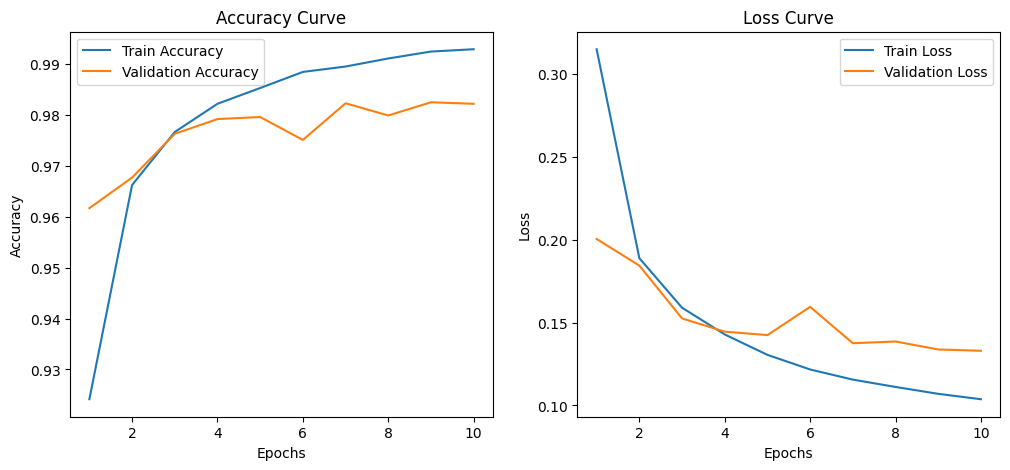

In [21]:
# Helper plotting function
#
# history: the history object returned by the training function
def plot_curve(history):
    """
    Plots the learning curves for accuracy and loss.

    history: Dictionary containing 'accuracy', 'val_accuracy', 'loss', 'val_loss' per epoch.
    """
    epochs = range(1, len(history["accuracy"]) + 1)

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["accuracy"], label="Train Accuracy")
    plt.plot(epochs, history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.show()

model = create_model()
model.to(device)

history = train_model(model, train_dataset, val_dataset)

plot_curve(history)


## Exercise 5: Optimize the model

Try to optimize the model, either manually or with a tuning method. At least optimize the following:
* the number of hidden layers 
* the number of nodes in each layer
* the amount of dropout layers and the dropout rate

Try to reach at least 96% accuracy against the test set.

In [22]:
def evaluate_model(model, test_dataset, batch_size=64):
   """
   Evaluates the model on test data
   
   model: the trained model to evaluate
   test_dataset: the test data and labels
   batch_size: batch size for evaluation
   
   Returns:
       test_loss: average loss over the test set
       test_accuracy: accuracy over the test set
   """
   model.eval()  # Set model to evaluation mode
   
   test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=4, 
                            shuffle=False, pin_memory=False)
   cross_entropy = nn.CrossEntropyLoss(label_smoothing=0.01)
   accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=10)
   
   test_loss, test_correct, test_total = 0, 0, 0
   
   with torch.no_grad():  # No need to track gradients during evaluation
       for X_test, y_test in test_loader:
           X_test, y_test = X_test.to(device), y_test.to(device)
           
           test_outputs = model(X_test)
           t_loss = cross_entropy(test_outputs, y_test)
           
           test_loss += t_loss.item()
           test_correct += accuracy_metric(test_outputs, y_test).item() * y_test.size(0)
           test_total += y_test.size(0)
   
   # Calculate average metrics
   avg_test_loss = test_loss / len(test_loader)
   avg_test_accuracy = test_correct / test_total
   
   print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {avg_test_accuracy:.4f}")
   
   return avg_test_loss, avg_test_accuracy

avg_test_loss, avg_test_accuracy = evaluate_model(model, test_dataset)

Test Loss: 0.1329, Test Accuracy: 0.9822
